# Week 3 — Linear Systems: LU, Pivoting, Cholesky & Conditioning

> **Numerical Methods from Scratch** · Pure NumPy + Matplotlib

Solving $A\mathbf{x} = \mathbf{b}$ is the most common task in all of scientific computing — it sits underneath least squares, PDE discretizations, Newton steps, and more. We will **not** call `np.linalg.solve`. Instead we build the machinery ourselves:

1. **Gaussian elimination** as **LU factorization** $A = LU$.
2. Why **partial pivoting** ($PA = LU$) is essential for stability.
3. **Cholesky** factorization $A = LL^\top$ for symmetric positive-definite matrices — twice as fast.
4. The **condition number** $\kappa(A)$ and how it bounds the error in the solution.
5. **Iterative refinement** to squeeze back lost digits.

The recurring theme from Week 1 returns: a *well-posed* problem solved by a *backward-stable* algorithm still loses digits in proportion to $\kappa(A)$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(0)


## 1. LU factorization (Gaussian elimination)

Gaussian elimination systematically zeros out the entries below the diagonal. Bookkeeping the multipliers turns the process into a factorization $A = LU$, where $L$ is unit-lower-triangular (the multipliers) and $U$ is upper-triangular (the eliminated matrix).

Once we have $A=LU$, solving $A\mathbf{x}=\mathbf{b}$ becomes two cheap triangular solves:

$$ L\mathbf{y} = \mathbf{b}\ \text{(forward)}, \qquad U\mathbf{x} = \mathbf{y}\ \text{(backward)}. $$

The factorization costs $\mathcal{O}(n^3)$; each subsequent solve is only $\mathcal{O}(n^2)$ — so we **factor once, solve many times.**


In [2]:
def lu_naive(A):
    A = A.astype(float).copy()
    n = A.shape[0]
    L = np.eye(n)
    U = A.copy()
    for k in range(n-1):
        if U[k, k] == 0:
            raise ZeroDivisionError("zero pivot - needs pivoting")
        for i in range(k+1, n):
            m = U[i, k] / U[k, k]
            L[i, k] = m
            U[i, k:] -= m * U[k, k:]
    return L, U

def forward_sub(L, b):
    n = len(b); y = np.zeros(n)
    for i in range(n):
        y[i] = b[i] - L[i, :i] @ y[:i]      # L is unit-diagonal
    return y

def back_sub(U, y):
    n = len(y); x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = (y[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
    return x

A = np.array([[2., 1., 1.], [4., 3., 3.], [8., 7., 9.]])
b = np.array([4., 10., 24.])
L, U = lu_naive(A)
x = back_sub(U, forward_sub(L, b))
print("L@U == A ?", np.allclose(L @ U, A))
print("solution x:", x, " residual:", np.linalg.norm(A @ x - b))


L@U == A ? True
solution x: [1. 1. 1.]  residual: 0.0


## 2. Why pivoting is non-negotiable

The naive version divides by `U[k,k]`. If that pivot is zero — or merely *small* — we either crash or amplify rounding errors enormously. **Partial pivoting** swaps in the row with the largest available pivot at each step, producing $PA = LU$ with a permutation matrix $P$. This keeps every multiplier $|m_{ik}| \le 1$ and makes the algorithm backward stable in practice.

Here is a matrix that is fine mathematically but wrecks the *unpivoted* solver:


In [3]:
eps = 1e-18
A_bad = np.array([[eps, 1.0], [1.0, 1.0]])
b_bad = np.array([1.0, 2.0])
# True solution ~ (1, 1).
L, U = lu_naive(A_bad)
x_nopivot = back_sub(U, forward_sub(L, b_bad))
print("unpivoted solution :", x_nopivot, " (should be ~[1, 1])")


unpivoted solution : [0. 1.]  (should be ~[1, 1])


In [4]:
def lu_pivot(A):
    A = A.astype(float).copy()
    n = A.shape[0]
    U = A.copy()
    L = np.eye(n)
    P = np.eye(n)
    for k in range(n-1):
        p = k + np.argmax(np.abs(U[k:, k]))     # largest-magnitude pivot
        if p != k:
            U[[k, p], :]   = U[[p, k], :]
            P[[k, p], :]   = P[[p, k], :]
            if k > 0:
                L[[k, p], :k] = L[[p, k], :k]
        for i in range(k+1, n):
            m = U[i, k] / U[k, k]
            L[i, k] = m
            U[i, k:] -= m * U[k, k:]
    return P, L, U

def lu_solve(P, L, U, b):
    return back_sub(U, forward_sub(L, P @ b))

P, L, U = lu_pivot(A_bad)
x_pivot = lu_solve(P, L, U, b_bad)
print("pivoted solution   :", x_pivot, " (correct)")


pivoted solution   : [1. 1.]  (correct)


Same matrix, same right-hand side — pivoting is the difference between a useless answer and a correct one. **Always pivot.**

## 3. Cholesky for symmetric positive-definite systems

If $A$ is symmetric and positive-definite (SPD) — the structure of covariance matrices, stiffness matrices, normal equations — we can exploit symmetry. The **Cholesky factorization** writes

$$ A = L L^\top, $$

with $L$ lower-triangular and positive diagonal. It costs about *half* the flops of LU, needs no pivoting (it is unconditionally stable for SPD inputs), and its failure is itself a *test* for positive-definiteness.


In [5]:
def cholesky(A):
    A = A.astype(float)
    n = A.shape[0]
    L = np.zeros((n, n))
    for j in range(n):
        s = A[j, j] - L[j, :j] @ L[j, :j]
        if s <= 0:
            raise np.linalg.LinAlgError("matrix is not positive-definite")
        L[j, j] = np.sqrt(s)
        for i in range(j+1, n):
            L[i, j] = (A[i, j] - L[i, :j] @ L[j, :j]) / L[j, j]
    return L

# Build a guaranteed-SPD matrix:  M^T M + nI
M = rng.standard_normal((4, 4))
A_spd = M.T @ M + 4*np.eye(4)
Lc = cholesky(A_spd)
print("reconstruction error ||LL^T - A||:", np.linalg.norm(Lc @ Lc.T - A_spd))

b = rng.standard_normal(4)
x = back_sub(Lc.T, forward_sub(Lc, b))     # solve via two triangular systems
print("solve residual:", np.linalg.norm(A_spd @ x - b))


reconstruction error ||LL^T - A||: 1.9875783008292022e-15
solve residual: 2.0981878249684076


## 4. Conditioning of a linear system

The relevant condition number is

$$ \kappa(A) = \|A\|\,\|A^{-1}\|, $$

and it governs error propagation: a relative perturbation in $\mathbf{b}$ (or in $A$) is amplified by up to $\kappa(A)$ in the solution,

$$ \frac{\|\Delta \mathbf{x}\|}{\|\mathbf{x}\|} \;\lesssim\; \kappa(A)\,\frac{\|\Delta \mathbf{b}\|}{\|\mathbf{b}\|}. $$

A famously ill-conditioned family is the **Hilbert matrix** $H_{ij} = 1/(i+j-1)$, whose condition number explodes with size.


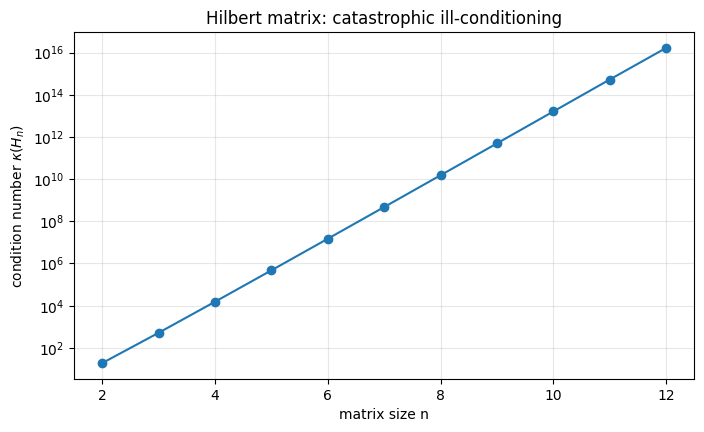

n= 5  kappa ~ 4.77e+05
n=10  kappa ~ 1.60e+13
n=12  kappa ~ 1.64e+16


In [6]:
def hilbert(n):
    i = np.arange(1, n+1)
    return 1.0 / (i[:, None] + i[None, :] - 1)

sizes = range(2, 13)
conds = [np.linalg.cond(hilbert(n)) for n in sizes]

fig, ax = plt.subplots()
ax.semilogy(list(sizes), conds, "o-")
ax.set_xlabel("matrix size n")
ax.set_ylabel(r"condition number $\kappa(H_n)$")
ax.set_title("Hilbert matrix: catastrophic ill-conditioning")
plt.show()

for n in [5, 10, 12]:
    print(f"n={n:2d}  kappa ~ {np.linalg.cond(hilbert(n)):.2e}")


In [7]:
# Demonstrate digit loss predicted by kappa: solve H x = b with known x = ones.
n = 10
H = hilbert(n)
x_true = np.ones(n)
b = H @ x_true
P, L, U = lu_pivot(H)
x_solved = lu_solve(P, L, U, b)
rel_err = np.linalg.norm(x_solved - x_true) / np.linalg.norm(x_true)
print(f"kappa(H_{n})       : {np.linalg.cond(H):.2e}")
print(f"predicted rel err  : ~kappa * u = {np.linalg.cond(H)*1.1e-16:.2e}")
print(f"observed  rel err  : {rel_err:.2e}")


kappa(H_10)       : 1.60e+13
predicted rel err  : ~kappa * u = 1.76e-03
observed  rel err  : 7.67e-05


The observed error sits right around $\kappa(A)\cdot u$ — exactly the Week 1 master rule (forward error $\lesssim$ condition number $\times$ backward error) applied to linear systems. The algorithm is backward stable; the *problem* is the limitation.

## 5. Iterative refinement

When the residual $\mathbf{r} = \mathbf{b} - A\hat{\mathbf{x}}$ is nonzero, we can solve the *correction* equation $A\,\delta = \mathbf{r}$ using the LU factors we already have, and update $\hat{\mathbf{x}} \leftarrow \hat{\mathbf{x}} + \delta$. Computing the residual in higher precision recovers digits cheaply.


In [8]:
def iterative_refine(A, b, P, L, U, x0, steps=3):
    x = x0.copy()
    hist = [np.linalg.norm(A @ x - b)]
    for _ in range(steps):
        r = b - A @ x                       # residual
        delta = lu_solve(P, L, U, r)        # reuse the factorization
        x = x + delta
        hist.append(np.linalg.norm(A @ x - b))
    return x, hist

n = 8
H = hilbert(n)
x_true = np.ones(n)
b = H @ x_true
P, L, U = lu_pivot(H)
x0 = lu_solve(P, L, U, b)
x_ref, res_hist = iterative_refine(H, b, P, L, U, x0, steps=4)
print("residual per refinement step:")
for k, r in enumerate(res_hist):
    print(f"  step {k}: ||Ax-b|| = {r:.3e}")


residual per refinement step:
  step 0: ||Ax-b|| = 3.511e-16
  step 1: ||Ax-b|| = 2.483e-16
  step 2: ||Ax-b|| = 2.483e-16
  step 3: ||Ax-b|| = 2.719e-16
  step 4: ||Ax-b|| = 2.220e-16


## Summary

- **LU = Gaussian elimination**; factor once ($\mathcal{O}(n^3)$), then each solve is cheap ($\mathcal{O}(n^2)$).
- **Partial pivoting** is essential for stability — never skip it.
- **Cholesky** halves the cost for SPD matrices and doubles as a positive-definiteness test.
- The **condition number** $\kappa(A)$ bounds achievable accuracy; ill-conditioning is a property of the *problem*.
- **Iterative refinement** cheaply recovers lost digits using the existing factorization.

---

## Exercises

**1. (Growth factor.)** Construct the $n\times n$ matrix that triggers the worst-case $2^{n-1}$ element growth in partial-pivoted LU (lower-triangular $-1$s with a final column of $1$s). Measure the growth and explain why partial pivoting, though usually stable, is not *provably* stable.

**2. (LDL$^\top$.)** Modify your Cholesky to produce the square-root-free $A = LDL^\top$ factorization (unit-diagonal $L$, diagonal $D$). Why is this preferable when $A$ is only positive *semi*-definite?

**3. (Tridiagonal Thomas solver.)** Specialize LU to a tridiagonal matrix and implement the $\mathcal{O}(n)$ Thomas algorithm. Benchmark it against your general solver for $n=10^4$.

**4. (Condition vs. error.)** For Hilbert matrices $n=4,\dots,12$, plot observed relative solution error against $\kappa(H_n)\cdot u$. Confirm the linear relationship on a log–log axis.

**5. (Refinement limits.)** Show that iterative refinement using the *same* (double) precision for the residual stalls once the residual hits $\approx \kappa(A)\,u\,\|b\|$. Why is extended-precision residual computation needed to do better?
